In [1]:
# !mkdir /root/.config/kaggle

In [2]:
# !cp kaggle.json /root/.config/kaggle/

In [3]:
# !kaggle datasets download anthonytherrien/dog-vs-cat

In [4]:
# !unzip /content/dog-vs-cat.zip

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

In [6]:
data_dir = "/content/animals"
img_height = 180
img_width = 180
batch_size = 32

In [7]:
import os
from PIL import Image

data_dir = "/content/animals"
num_removed = 0

print("Starting robust scan...")

for folder_name in ("cat", "dog"):
    folder_path = os.path.join(data_dir, folder_name)
    print(f"Scanning folder: {folder_path}")

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with Image.open(fpath) as img:
                img.load()
        except Exception as e:
            print(f"Corrupted file found, removing: {fpath} ({e})")
            os.remove(fpath)
            num_removed += 1

print(f"\nRobust scan complete. Removed {num_removed} additional corrupted files.")

Starting robust scan...
Scanning folder: /content/animals/cat
Scanning folder: /content/animals/dog

Robust scan complete. Removed 0 additional corrupted files.


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [10]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [11]:
class_names = train_ds.class_names
class_names

['cat', 'dog']

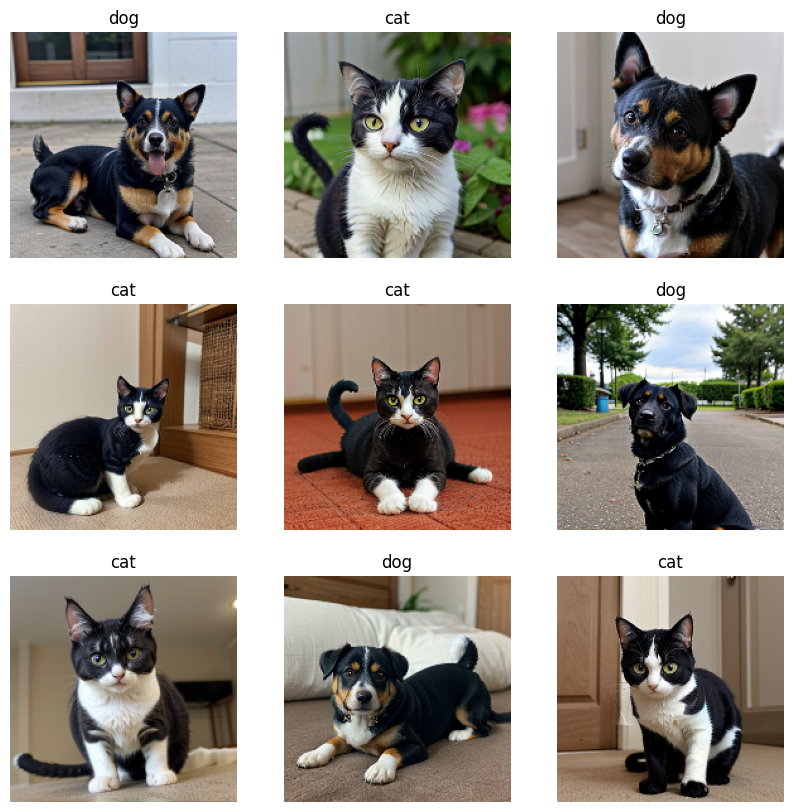

In [22]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [14]:
from keras import layers
from keras import models

model = models.Sequential()
model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,550,273 (21.17 MB)

 Trainable params: 5,550,273 (21.17 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.4889 - loss: 0.8658 - val_accuracy: 0.5900 - val_loss: 0.6785
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.5817 - loss: 0.6440 - val_accuracy: 0.8050 - val_loss: 0.4313
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.7417 - loss: 0.4551 - val_accuracy: 0.8650 - val_loss: 0.3509
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.8178 - loss: 0.3768 - val_accuracy: 0.9000 - val_loss: 0.2303
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.8937 - loss: 0.2570 - val_accuracy: 0.9000 - val_loss: 0.2178
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.9274 - loss: 0.1957 - val_accuracy: 0.9300 - val_loss: 0.1801
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9579 - loss: 0.1063 - val_accuracy: 0.9600 - val_loss: 0.1486
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9715 - loss: 0.0695 - val_accuracy: 0.95

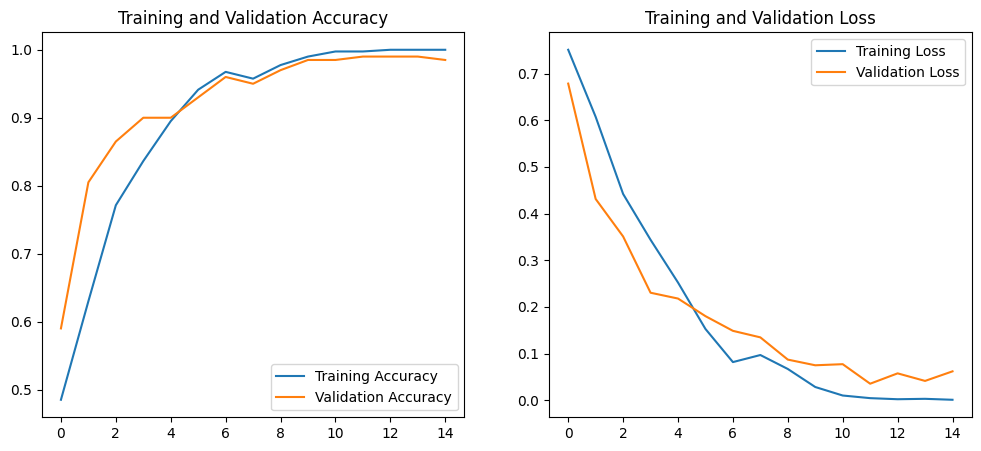

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(15)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()